
High-order spherical harmonic biplanar coil design
==================================================

Example showing a basic biplanar coil producing a high-order spherical harmonic field
in a specific target region between the two coil planes.


In [ ]:
import numpy as np
from mayavi import mlab
import trimesh
%matplotlib inline

from bfieldtools.mesh_conductor import MeshConductor
from bfieldtools.coil_optimize import optimize_streamfunctions
from bfieldtools.utils import combine_meshes, load_example_mesh


# Load simple plane mesh that is centered on the origin
planemesh = load_example_mesh("10x10_plane_hires")

# Specify coil plane geometry
center_offset = np.array([0, 0, 0])
standoff = np.array([0, 3, 0])

# Create coil plane pairs
coil_plus = trimesh.Trimesh(
    planemesh.vertices + center_offset + standoff, planemesh.faces, process=False
)

coil_minus = trimesh.Trimesh(
    planemesh.vertices + center_offset - standoff, planemesh.faces, process=False
)

joined_planes = combine_meshes((coil_plus, coil_minus))

# Create mesh class object
coil = MeshConductor(
    mesh_obj=joined_planes, fix_normals=True, basis_name="suh", N_suh=100
)

Intel MKL WARNING: Support of Intel(R) Streaming SIMD Extensions 4.2 (Intel(R) SSE4.2) enabled only processors has been deprecated. Intel oneAPI Math Kernel Library 2025.0 will require Intel(R) Advanced Vector Extensions (Intel(R) AVX) instructions.
Intel MKL WARNING: Support of Intel(R) Streaming SIMD Extensions 4.2 (Intel(R) SSE4.2) enabled only processors has been deprecated. Intel oneAPI Math Kernel Library 2025.0 will require Intel(R) Advanced Vector Extensions (Intel(R) AVX) instructions.
Calculating surface harmonics expansion...
Computing the laplacian matrix...
Computing the mass matrix...
Intel MKL WARNING: Support of Intel(R) Streaming SIMD Extensions 4.2 (Intel(R) SSE4.2) enabled only processors has been deprecated. Intel oneAPI Math Kernel Library 2025.0 will require Intel(R) Advanced Vector Extensions (Intel(R) AVX) instructions.
Intel MKL WARNING: Support of Intel(R) Streaming SIMD Extensions 4.2 (Intel(R) SSE4.2) enabled only processors has been deprecated. Intel oneAPI

Set up target and stray field points



In [2]:
# Here, the target points are on a volumetric grid within a sphere

center = np.array([0, 0, 0])

sidelength = 1.5
n = 8
xx = np.linspace(-sidelength / 2, sidelength / 2, n)
yy = np.linspace(-sidelength / 2, sidelength / 2, n)
zz = np.linspace(-sidelength / 2, sidelength / 2, n)
X, Y, Z = np.meshgrid(xx, yy, zz, indexing="ij")

x = X.ravel()
y = Y.ravel()
z = Z.ravel()

target_points = np.array([x, y, z]).T

# Turn cube into sphere by rejecting points "in the corners"
target_points = (
    target_points[np.linalg.norm(target_points, axis=1) < sidelength / 2] + center
)

Create bfield specifications used when optimizing the coil geometry



/Users/andrei/miniconda3/envs/bfieldtools_env/lib/python3.12/site-packages/pyvista/jupyter/notebook.py:56: UserWarning: Failed to use notebook backend: 

cannot import name 'vuetify' from 'trame.widgets' (/Users/andrei/miniconda3/envs/bfieldtools_env/lib/python3.12/site-packages/trame/widgets/__init__.py)

Falling back to a static output.
  warnings.warn(


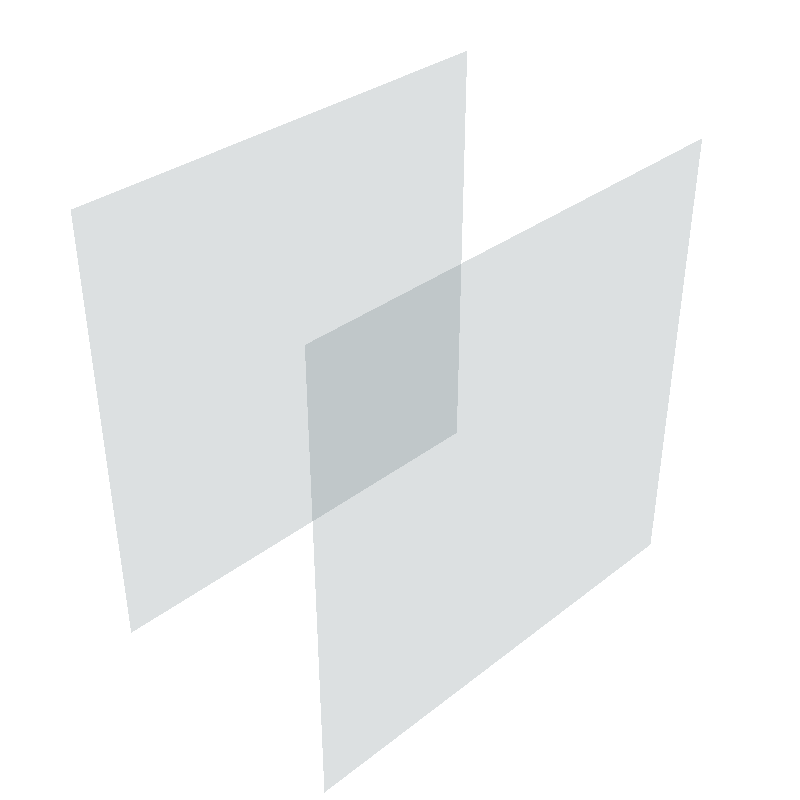

In [4]:
from bfieldtools import sphtools


lmax = 4
alm = np.zeros((lmax * (lmax + 2),))
blm = np.zeros((lmax * (lmax + 2),))

# Set one specific component to one
blm[16] += 1

sphfield = sphtools.field(target_points, alm, blm, lmax)

target_field = sphfield / np.max(sphfield[:, 0])


coil.plot_mesh(opacity=0.2)
#mlab.quiver3d(*target_points.T, *sphfield.T)


target_spec = {
    "coupling": coil.B_coupling(target_points),
    "abs_error": 0.1,
    "target": target_field,
}

Run QP solver



In [5]:
import mosek

coil.s, prob = optimize_streamfunctions(
    coil,
    [target_spec],
    objective="minimum_inductive_energy",
    solver="MOSEK",
    solver_opts={"mosek_params": {mosek.iparam.num_threads: 8}},
)

Computing the inductance matrix...
Computing self-inductance matrix using rough quadrature (degree=2).              For higher accuracy, set quad_degree to 4 or more.
Estimating 34964 MiB required for 3184 by 3184 vertices...
Computing inductance matrix in 880 chunks (809 MiB memory free),              when approx_far=True using more chunks is faster...
Computing triangle-coupling matrix


(CVXPY) Nov 20 11:43:12 AM: Your problem has 100 variables, 960 constraints, and 0 parameters.
(CVXPY) Nov 20 11:43:12 AM: It is compliant with the following grammars: DCP, DQCP
(CVXPY) Nov 20 11:43:12 AM: (If you need to solve this problem multiple times, but with different data, consider using parameters.)
(CVXPY) Nov 20 11:43:12 AM: CVXPY will first compile your problem; then, it will invoke a numerical solver to obtain a solution.
(CVXPY) Nov 20 11:43:12 AM: Your problem is compiled with the CPP canonicalization backend.
(CVXPY) Nov 20 11:43:12 AM: Compiling problem (target solver=MOSEK).
(CVXPY) Nov 20 11:43:12 AM: Reduction chain: Dcp2Cone -> CvxAttr2Constr -> ConeMatrixStuffing -> MOSEK
(CVXPY) Nov 20 11:43:12 AM: Applying reduction Dcp2Cone
(CVXPY) Nov 20 11:43:12 AM: Applying reduction CvxAttr2Constr
(CVXPY) Nov 20 11:43:12 AM: Applying reduction ConeMatrixStuffing
(CVXPY) Nov 20 11:43:12 AM: Applying reduction MOSEK
(CVXPY) Nov 20 11:43:12 AM: Finished problem compilation (to

Inductance matrix computation took 19.56 seconds.
Passing problem to solver...
                                     CVXPY                                     
                                     v1.7.3                                    
-------------------------------------------------------------------------------
                                  Compilation                                  
-------------------------------------------------------------------------------
-------------------------------------------------------------------------------
                                Numerical solver                               
-------------------------------------------------------------------------------




/Users/andrei/miniconda3/envs/bfieldtools_env/lib/python3.12/site-packages/cvxpy/reductions/solvers/conic_solvers/mosek_conif.py:680: UserWarning: 
Using MOSEK constants to specify parameters is deprecated.
Use generic string names instead.
For example, replace mosek.iparam.num_threads with 'MSK_IPAR_NUM_THREADS'

  warnings.warn(__MSK_ENUM_PARAM_DEPRECATION__, UserWarning)
(CVXPY) Nov 20 11:43:12 AM: Problem
(CVXPY) Nov 20 11:43:12 AM:   Name                   :                 
(CVXPY) Nov 20 11:43:12 AM:   Objective sense        : maximize        
(CVXPY) Nov 20 11:43:12 AM:   Type                   : CONIC (conic optimization problem)
(CVXPY) Nov 20 11:43:12 AM:   Constraints            : 101             
(CVXPY) Nov 20 11:43:12 AM:   Affine conic cons.     : 0               
(CVXPY) Nov 20 11:43:12 AM:   Disjunctive cons.      : 0               
(CVXPY) Nov 20 11:43:12 AM:   Cones                  : 1               
(CVXPY) Nov 20 11:43:12 AM:   Scalar variables       : 1062      

-------------------------------------------------------------------------------
                                    Summary                                    
-------------------------------------------------------------------------------


Plot coil windings and target points



Processing contour, value: -984370247.2275404
Processing contour, value: -765615460.2623397
Processing contour, value: -546860673.297139
Processing contour, value: -328105886.3319384
Processing contour, value: -109351099.36673772
Processing contour, value: 109403687.59846306
Processing contour, value: 328158474.5636635
Processing contour, value: 546913261.5288644
Processing contour, value: 765668048.4940648
Processing contour, value: 984422835.4592657


/Users/andrei/miniconda3/envs/bfieldtools_env/lib/python3.12/site-packages/pyvista/jupyter/notebook.py:56: UserWarning: Failed to use notebook backend: 

cannot import name 'vuetify' from 'trame.widgets' (/Users/andrei/miniconda3/envs/bfieldtools_env/lib/python3.12/site-packages/trame/widgets/__init__.py)

Falling back to a static output.
  warnings.warn(


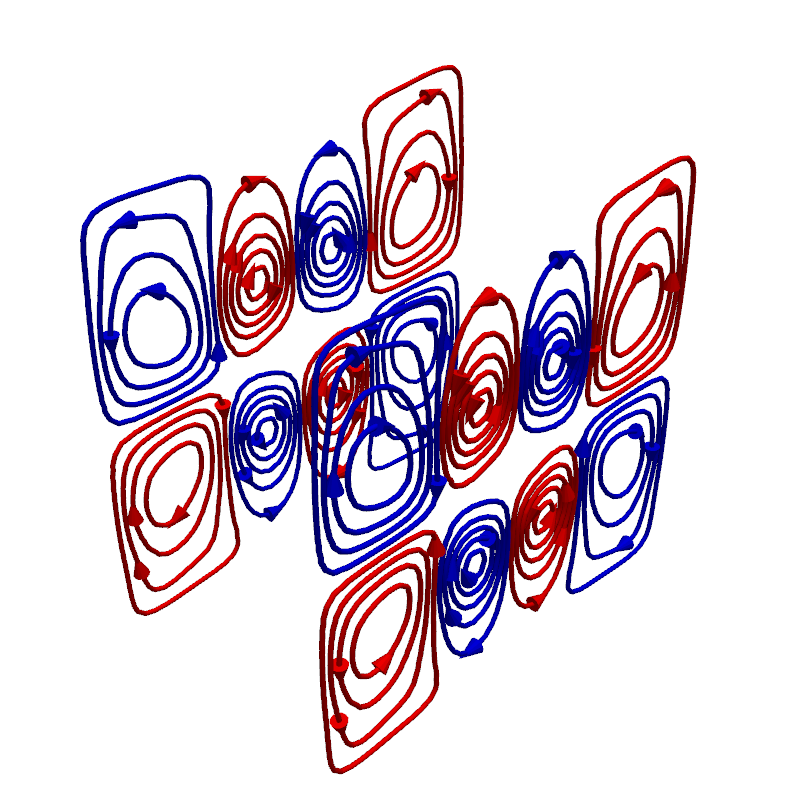

In [6]:
coil.s.discretize(N_contours=10).plot_loops()

# PICMOT

In [19]:
import numpy as np
import trimesh

from bfieldtools.mesh_conductor import MeshConductor
from bfieldtools.coil_optimize import optimize_streamfunctions
from bfieldtools.utils import combine_meshes, load_example_mesh
from bfieldtools import sphtools  # not strictly needed here, but useful if you later switch to SH targets

# ---------------------------------------------------------
# Geometry parameters
# ---------------------------------------------------------

# Board size: 100 mm x 100 mm
board_size = 0.10  # [m]
board_half = board_size / 2

# Board z-positions
z1 = -2e-3  # [m]
z2 = -3e-3  # [m]

# MOT / gradient center
z0 = 9.8e-3  # [m]
target_center = np.array([0.0, 0.0, z0])

# Desired quadrupole gradient magnitude (set your target value here)
# Units are arbitrary but consistent; e.g. T/m if everything is in SI.
G_Gpercm = 10.0  # [G/cm]
G_target = G_Gpercm * 1e-2  # [T/m]

# ---------------------------------------------------------
# Build coil surfaces: two 100 x 100 mm planes at z1, z2
# ---------------------------------------------------------

# Load example plane mesh (nominally 10 x 10 units, centered at origin)
planemesh = load_example_mesh("10x10_plane_hires")

# Scale so that the plane is 0.10 x 0.10 m.
# Assumption: original "10x10" mesh spans [-5, 5] in x and y → width = 10.
scale = board_size / 10.0  # 0.1 / 10 = 0.01
planemesh.apply_scale(scale)

# Now planemesh is ~100 mm x 100 mm centered at origin in x,y, lying at z=0.

# Create two copies at z1 and z2
verts = planemesh.vertices
faces = planemesh.faces

coil1_mesh = trimesh.Trimesh(
    vertices=verts + np.array([0.0, 0.0, z1]),
    faces=faces,
    process=False,
)

coil2_mesh = trimesh.Trimesh(
    vertices=verts + np.array([0.0, 0.0, z2]),
    faces=faces,
    process=False,
)

# Combine into one mesh and wrap in MeshConductor
joined_planes = combine_meshes((coil1_mesh, coil2_mesh))

coil = MeshConductor(
    mesh_obj=joined_planes,
    fix_normals=True,
    basis_name="suh",   # surface harmonics basis
    N_suh=100           # number of basis functions (tune for accuracy/speed)
)

# ---------------------------------------------------------
# Define target points around z0
# ---------------------------------------------------------

# We’ll define a small spherical ROI around the MOT/gradient center
roi_sidelength = 4e-3  # 4 mm cube
n = 8                  # number of sample points per dimension

xx = np.linspace(-roi_sidelength / 2, roi_sidelength / 2, n)
yy = np.linspace(-roi_sidelength / 2, roi_sidelength / 2, n)
zz = np.linspace(-roi_sidelength / 2, roi_sidelength / 2, n)

X, Y, Z = np.meshgrid(xx, yy, zz, indexing="ij")

# Shift cube so it’s centered at (0, 0, z0)
x = X.ravel()
y = Y.ravel()
z = Z.ravel() + z0

target_points = np.vstack((x, y, z)).T

# Optional: restrict to a sphere, not the whole cube
r_rel = target_points - target_center
rad = np.linalg.norm(r_rel, axis=1)

roi_radius = roi_sidelength / 2
mask = rad < roi_radius
target_points = target_points[mask]
r_rel = r_rel[mask]

# ---------------------------------------------------------
# Define a quadrupole target field with B(z0) = 0
# ---------------------------------------------------------
# Standard quadrupole form that satisfies ∇·B = 0:
#   Bx =  (G/2) * x'
#   By =  (G/2) * y'
#   Bz =   -G   * z'
# where (x', y', z') = (x - x0, y - y0, z - z0).
# This has B = 0 at (x0, y0, z0) and constant gradient.

x_rel = r_rel[:, 0]
y_rel = r_rel[:, 1]
z_rel = r_rel[:, 2]

B_target = np.zeros_like(target_points)
B_target[:, 0] = 0.5 * G_target * x_rel
B_target[:, 1] = 0.5 * G_target * y_rel
B_target[:, 2] = -1.0 * G_target * z_rel

# Normalize the target field so the max magnitude is 1 (helps conditioning)
normB = np.linalg.norm(B_target, axis=1)
maxB = normB.max()
if maxB > 0:
    target_field = B_target / maxB
else:
    raise RuntimeError("Target field is identically zero; check parameters.")

Calculating surface harmonics expansion...
Computing the laplacian matrix...
Computing the mass matrix...
Intel MKL WARNING: Support of Intel(R) Streaming SIMD Extensions 4.2 (Intel(R) SSE4.2) enabled only processors has been deprecated. Intel oneAPI Math Kernel Library 2025.0 will require Intel(R) Advanced Vector Extensions (Intel(R) AVX) instructions.
Intel MKL WARNING: Support of Intel(R) Streaming SIMD Extensions 4.2 (Intel(R) SSE4.2) enabled only processors has been deprecated. Intel oneAPI Math Kernel Library 2025.0 will require Intel(R) Advanced Vector Extensions (Intel(R) AVX) instructions.
Intel MKL WARNING: Support of Intel(R) Streaming SIMD Extensions 4.2 (Intel(R) SSE4.2) enabled only processors has been deprecated. Intel oneAPI Math Kernel Library 2025.0 will require Intel(R) Advanced Vector Extensions (Intel(R) AVX) instructions.
Intel MKL WARNING: Support of Intel(R) Streaming SIMD Extensions 4.2 (Intel(R) SSE4.2) enabled only processors has been deprecated. Intel oneAPI

In [35]:
# ---------------------------------------------------------
# Build bfieldtools “specification” and run optimizer (MOSEK)
# ---------------------------------------------------------

from bfieldtools.coil_optimize import optimize_streamfunctions
import mosek

# Magnetic field coupling matrix from coil streamfunction to target points
B_coupling = coil.B_coupling(target_points)

target_spec = {
    "coupling": B_coupling,
    "abs_error": 100.0,       # allowed RMS relative error (tune this)
    "target": target_field,  # desired B at target points
}

# Mix inductive energy + a bit of ohmic power for numerical stability
# (pure "minimum_inductive_energy" can give a non–PD quadratic matrix)
objective = (1.0, 0.05)   # (inductive_weight, resistive_weight)

solver_name = "MOSEK"
solver_opts = {
    "mosek_params": {
        mosek.iparam.num_threads: 8,
        # You can tweak tolerances if needed:
        # mosek.dparam.intpnt_co_tol_rel_gap: 1e-7,
    }
}

# Run convex optimization over stream function with MOSEK
coil.s, prob = optimize_streamfunctions(
    coil,
    [target_spec],
    objective=objective,
    solver=solver_name,
    solver_opts=solver_opts,
)

# store on coil for later use if you like
sf = coil.s

print("MOSEK status:", prob.status)

if prob.status not in ("optimal", "optimal_inaccurate"):
    raise RuntimeError(f"MOSEK did not converge to an optimal solution: {prob.status}")

# ---------------------------------------------------------
# Check that B ~ 0 at z0 and that gradient is non-zero
# ---------------------------------------------------------

# Evaluate B at a few points near the center to inspect gradient
probe_offsets = np.array([
    [0.0,  0.0,  0.0],
    [1e-3, 0.0,  0.0],
    [-1e-3,0.0,  0.0],
    [0.0,  1e-3, 0.0],
    [0.0, -1e-3, 0.0],
    [0.0,  0.0,  1e-3],
    [0.0,  0.0, -1e-3],
])

probe_points = target_center[None, :] + probe_offsets

# Compute coupling and field at probe points
coil.B_coupling.reset()
B_probe_coupling = coil.B_coupling(probe_points, analytic=True)   # (N_pts, N_verts, 3)

# sf is already a StreamFunction object; sf.vert is the vertex-basis streamfunction (N_verts,)
# B_probe = np.einsum("ijk,j->ik", B_probe_coupling, sf.coeffs)

# print("Probe points (m) relative to center:\n", probe_offsets)
# print("B field at probes (arb. units):\n", B_probe)

# # Quick sanity checks
# B0 = B_probe[0]
# print("||B(center)||:", np.linalg.norm(B0))

# dz = 1e-3
# Bz_plus  = B_probe[5, 2]
# Bz_minus = B_probe[6, 2]
# Gz_est   = (Bz_plus - Bz_minus) / (2 * dz)
# print("Estimated dBz/dz at center (arb units/m):", Gz_est)

Computing magnetic field coupling matrix, 3184 vertices by 160 target points... 

(CVXPY) Nov 20 12:09:01 PM: Your problem has 100 variables, 960 constraints, and 0 parameters.
(CVXPY) Nov 20 12:09:01 PM: It is compliant with the following grammars: DCP, DQCP
(CVXPY) Nov 20 12:09:01 PM: (If you need to solve this problem multiple times, but with different data, consider using parameters.)
(CVXPY) Nov 20 12:09:01 PM: CVXPY will first compile your problem; then, it will invoke a numerical solver to obtain a solution.
(CVXPY) Nov 20 12:09:01 PM: Your problem is compiled with the CPP canonicalization backend.
(CVXPY) Nov 20 12:09:01 PM: Compiling problem (target solver=MOSEK).
(CVXPY) Nov 20 12:09:01 PM: Reduction chain: Dcp2Cone -> CvxAttr2Constr -> ConeMatrixStuffing -> MOSEK
(CVXPY) Nov 20 12:09:01 PM: Applying reduction Dcp2Cone
(CVXPY) Nov 20 12:09:01 PM: Applying reduction CvxAttr2Constr
(CVXPY) Nov 20 12:09:01 PM: Applying reduction ConeMatrixStuffing


took 0.38 seconds.
Scaling inductance and resistance matrices before optimization.              This requires eigenvalue computation, hold on.
Passing problem to solver...
                                     CVXPY                                     
                                     v1.7.3                                    
-------------------------------------------------------------------------------
                                  Compilation                                  
-------------------------------------------------------------------------------


(CVXPY) Nov 20 12:09:01 PM: Applying reduction MOSEK
(CVXPY) Nov 20 12:09:01 PM: Finished problem compilation (took 6.182e-02 seconds).
(CVXPY) Nov 20 12:09:01 PM: Invoking solver MOSEK  to obtain a solution.
/Users/andrei/miniconda3/envs/bfieldtools_env/lib/python3.12/site-packages/cvxpy/reductions/solvers/conic_solvers/mosek_conif.py:680: UserWarning: 
Using MOSEK constants to specify parameters is deprecated.
Use generic string names instead.
For example, replace mosek.iparam.num_threads with 'MSK_IPAR_NUM_THREADS'

  warnings.warn(__MSK_ENUM_PARAM_DEPRECATION__, UserWarning)
(CVXPY) Nov 20 12:09:01 PM: Problem
(CVXPY) Nov 20 12:09:01 PM:   Name                   :                 
(CVXPY) Nov 20 12:09:01 PM:   Objective sense        : maximize        
(CVXPY) Nov 20 12:09:01 PM:   Type                   : CONIC (conic optimization problem)
(CVXPY) Nov 20 12:09:01 PM:   Constraints            : 101             
(CVXPY) Nov 20 12:09:01 PM:   Affine conic cons.     : 0               


-------------------------------------------------------------------------------
                                Numerical solver                               
-------------------------------------------------------------------------------


-------------------------------------------------------------------------------
                                    Summary                                    
-------------------------------------------------------------------------------
MOSEK status: optimal
Computing magnetic field coupling matrix analytically, 3184 vertices by 7 target points... took 0.05 seconds.


Processing contour, value: -1.9684703535312458e-07
Processing contour, value: -1.535235654030973e-07
Processing contour, value: -1.1020009545306996e-07
Processing contour, value: -6.687662550304266e-08
Processing contour, value: -2.355315555301535e-08
Processing contour, value: 1.9770314397011964e-08
Processing contour, value: 6.309378434703928e-08
Processing contour, value: 1.0641725429706659e-07
Processing contour, value: 1.4974072424709385e-07
Processing contour, value: 1.9306419419712117e-07


/Users/andrei/miniconda3/envs/bfieldtools_env/lib/python3.12/site-packages/pyvista/jupyter/notebook.py:56: UserWarning: Failed to use notebook backend: 

cannot import name 'vuetify' from 'trame.widgets' (/Users/andrei/miniconda3/envs/bfieldtools_env/lib/python3.12/site-packages/trame/widgets/__init__.py)

Falling back to a static output.
  warnings.warn(


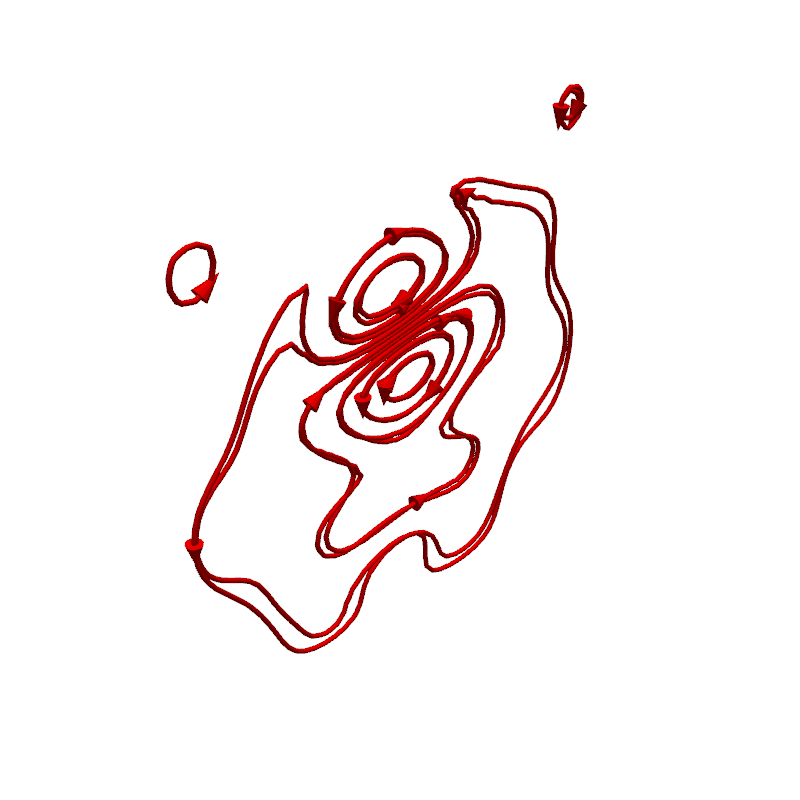

In [36]:
coil.s.discretize(N_contours=10).plot_loops()

In [37]:
B_probe = np.einsum("ijk,j->ik", B_probe_coupling, sf.inner)      # (N_pts, 3)

print("Probe points (m) relative to center:\n", probe_offsets)
print("B field at probes (arb. units):\n", B_probe)

# Quick sanity checks
B0 = B_probe[0]
print("||B(center)||:", np.linalg.norm(B0))

dz = 1e-3
Bz_plus  = B_probe[5, 2]
Bz_minus = B_probe[6, 2]
Gz_est   = (Bz_plus - Bz_minus) / (2 * dz)
print("Estimated dBz/dz at center (arb units/m):", Gz_est)

ValueError: operands could not be broadcast together with remapped shapes [original->remapped]: (7,3,100)->(7,100,3) (2896,)->(2896) 

In [40]:
import numpy as np
import matplotlib.pyplot as plt
from itertools import cycle


def plot_Bfield_along_beams_and_print_gradient_bfieldtools(
    coil,
    sf,
    beams_for_visualize,
    z0,
    mm_to_m,
    n=600,
    s_range_mm=10.0,
    to_gauss=True,
):
    """
    bfieldtools version of plot_Bfield_along_beams_and_print_gradient.

    Parameters
    ----------
    coil : bfieldtools.mesh_conductor.MeshConductor
        The coil/conductor object used to build coupling matrices.
    sf : bfieldtools.streamfunction.StreamFunction
        StreamFunction returned by optimize_streamfunctions (or optimize_lsq).
    beams_for_visualize : iterable
        List of "beam" objects. Each element can be:
          - a magpylib Line with .vertices (2x3),
          - or a 2x3 array-like of endpoints [[x1,y1,z1], [x2,y2,z2]].
    z0 : float
        z-coordinate of the beam intersection (in meters).
    mm_to_m : float
        Conversion factor from mm to m (e.g. 1e-3).
    n : int
        Number of sample points along each beam.
    s_range_mm : float
        Half-range of s around intersection in mm (default ±10 mm).
    to_gauss : bool
        If True, convert from Tesla to Gauss (×1e4).
    """

    # --- figure out the coefficients in the basis used by B_coupling ---
    # B_coupling(...).shape = (N_points, 3, N_basis)
    # We need a coefficient vector of length N_basis.
    def get_inner_coeffs(coil, sf):
        # If sf has an 'inner' attribute with correct length, use it
        if hasattr(sf, "inner"):
            # We'll verify length matches a sample coupling later
            return sf.inner
        # Otherwise, try projecting vertex basis -> inner basis
        if hasattr(coil, "basis_pinv") and hasattr(sf, "vert"):
            return coil.basis_pinv @ sf.vert
        # Fallback: assume sf.vert directly matches coupling last dim
        if hasattr(sf, "vert"):
            return sf.vert
        raise AttributeError("Cannot determine coefficient vector for this StreamFunction")

    # We'll check length against a small dummy coupling
    test_pts = np.array([[0.0, 0.0, z0]])
    coil.B_coupling.reset()
    test_cpl = coil.B_coupling(test_pts, analytic=True)      # (1, 3, N_basis)
    N_basis = test_cpl.shape[-1]

    coeffs = get_inner_coeffs(coil, sf)
    if coeffs.shape[0] != N_basis:
        # Try projecting vertex basis if we haven't already matched
        if hasattr(coil, "basis_pinv") and hasattr(sf, "vert"):
            coeffs = coil.basis_pinv @ sf.vert
        if coeffs.shape[0] != N_basis:
            raise ValueError(
                f"Coefficient length {coeffs.shape[0]} does not match coupling basis size {N_basis}"
            )

    # ---- Gather beam endpoints as plain (p1, p2) tuples ----
    beam_endpoints = []
    for b in beams_for_visualize:
        # magpylib Line-like: has .vertices
        if hasattr(b, "vertices"):
            v = np.array(b.vertices, dtype=float)
        else:
            # assume array-like [[x1,y1,z1],[x2,y2,z2]]
            v = np.array(b, dtype=float)
        if v.shape != (2, 3):
            raise ValueError("Each beam must define exactly 2 vertices (shape (2,3))")
        beam_endpoints.append((v[0], v[1]))

    # --- Plot B∥(s) with intersection at s=0 ---
    C = np.array([0.0, 0.0, z0], float)

    fig, ax = plt.subplots(figsize=(8, 5))

    linestyles = cycle(["-", "--", "-.", ":"])
    slope_G_per_cm_vals = []

    # s range around intersection, in meters
    s_max = s_range_mm * mm_to_m
    s_vals = np.linspace(-s_max, s_max, n)   # [m]

    for i, (p1, p2) in enumerate(beam_endpoints, start=1):
        # Beam direction unit vector
        u = p2 - p1
        L = np.linalg.norm(u)
        if L == 0:
            raise ValueError("Beam endpoints are identical.")
        u = u / L

        # Sample points along line through C: r(s) = C + s*u
        points = C[None, :] + s_vals[:, None] * u[None, :]

        # Compute B at all points
        coil.B_coupling.reset()
        B_cpl = coil.B_coupling(points, analytic=True)   # (n, 3, N_basis)
        # B(r_i) = sum_j B_cpl[i, :, j] * coeffs[j]
        B_vec = np.einsum("ijk,j->ik", B_cpl, coeffs)    # (n, 3)

        if to_gauss:
            B_vec = B_vec * 1e4  # Tesla -> Gauss

        # Project onto beam direction u: B_parallel = B · u
        B_par = B_vec @ u       # (n,)

        # Find slope dB||/ds at s=0
        idx0 = np.argmin(np.abs(s_vals))
        if idx0 == 0:
            ds = s_vals[1] - s_vals[0]
            dB = B_par[1] - B_par[0]
        elif idx0 == len(s_vals) - 1:
            ds = s_vals[-1] - s_vals[-2]
            dB = B_par[-1] - B_par[-2]
        else:
            ds = s_vals[idx0 + 1] - s_vals[idx0 - 1]
            dB = B_par[idx0 + 1] - B_par[idx0 - 1]

        # s in meters → G/m; to G/cm multiply by 0.01
        slope_G_per_cm = dB / ds * 0.01

        ls = next(linestyles)
        ax.plot(
            s_vals / mm_to_m,
            B_par,
            lw=2,
            ls=ls,
            label=f"Beam {i}: dB||/ds @ s=0 = {slope_G_per_cm:.1f} G/cm",
        )
        color = ax.lines[-1].get_color()
        ax.axvline(0, color=color, ls=ls, lw=1.2, alpha=0.7)

        print(f"Beam {i}: Slope dB||/ds at s=0: {slope_G_per_cm:.1f} G/cm")
        slope_G_per_cm_vals.append(slope_G_per_cm)

    ax.axhline(0, color="k", lw=0.8, alpha=0.5)
    ax.set_xlabel("Distance along beam from intersection s [mm]")
    ax.set_ylabel("B|| [G]" if to_gauss else "B|| [T]")
    ax.set_xlim(-s_range_mm, s_range_mm)
    ax.grid(True, alpha=0.3)
    ax.legend(loc="best")
    fig.suptitle("Magnetic field component along each beam (bfieldtools)")
    plt.tight_layout()
    plt.show()

    return slope_G_per_cm_vals